In [1]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
import random
from collections import namedtuple, defaultdict
from enum import Enum
import time

In [2]:
class Direction(Enum):
    RIGHT = 1
    LEFT = 2
    UP = 3
    DOWN = 4

# 定义点的位置
Point = namedtuple('Point', 'x, y')

In [3]:
class SnakeGameEnv:
    """贪吃蛇游戏环境类"""

    def __init__(self, width=20, height=20):
        self.width = width
        self.height = height
        self.reset()

    def reset(self):
        """重置游戏到初始状态"""
        self.direction = Direction.RIGHT
        head_x = self.width // 2
        head_y = self.height // 2
        self.head = Point(head_x, head_y)

        self.snake = [
            self.head,
            Point(self.head.x - 1, self.head.y),
            Point(self.head.x - 2, self.head.y)
        ]

        self.score = 0
        self.food = None
        self._place_food()
        self.frame_iteration = 0
        return self._get_state()

    def _place_food(self):
        """随机放置食物"""
        while True:
            x = random.randint(0, self.width - 1)
            y = random.randint(0, self.height - 1)
            self.food = Point(x, y)
            if self.food not in self.snake:
                break

    def step(self, action):
        """执行一个动作"""
        self.frame_iteration += 1
        self._update_direction(action)
        self._move()

        reward = 0
        done = False

        if self._is_collision() or self.frame_iteration > 100 * len(self.snake):
            done = True
            reward = -10
            return self._get_state(), reward, done, self.score

        if self.head == self.food:
            self.score += 1
            reward = 10
            self._place_food()
        else:
            self.snake.pop()

        reward -= 0.01
        return self._get_state(), reward, done, self.score

    def _update_direction(self, action):
        """更新移动方向"""
        clock_wise = [Direction.RIGHT, Direction.DOWN, Direction.LEFT, Direction.UP]
        idx = clock_wise.index(self.direction)

        if np.array_equal(action, [1, 0, 0]):
            new_dir = clock_wise[idx]
        elif np.array_equal(action, [0, 1, 0]):
            next_idx = (idx + 1) % 4
            new_dir = clock_wise[next_idx]
        else:
            next_idx = (idx - 1) % 4
            new_dir = clock_wise[next_idx]

        self.direction = new_dir

    def _move(self):
        """移动蛇头"""
        x = self.head.x
        y = self.head.y

        if self.direction == Direction.RIGHT:
            x += 1
        elif self.direction == Direction.LEFT:
            x -= 1
        elif self.direction == Direction.DOWN:
            y += 1
        elif self.direction == Direction.UP:
            y -= 1

        self.head = Point(x, y)
        self.snake.insert(0, self.head)

    def _is_collision(self, point=None):
        """检查碰撞"""
        if point is None:
            point = self.head

        if point.x < 0 or point.x >= self.width or point.y < 0 or point.y >= self.height:
            return True

        if point in self.snake[1:]:
            return True

        return False

    def _get_state(self):
        """获取当前状态（11维向量）"""
        head = self.head

        point_l = Point(head.x - 1, head.y)
        point_r = Point(head.x + 1, head.y)
        point_u = Point(head.x, head.y - 1)
        point_d = Point(head.x, head.y + 1)

        dir_l = self.direction == Direction.LEFT
        dir_r = self.direction == Direction.RIGHT
        dir_u = self.direction == Direction.UP
        dir_d = self.direction == Direction.DOWN

        state = [
            # 前方危险
            (dir_r and self._is_collision(point_r)) or
            (dir_l and self._is_collision(point_l)) or
            (dir_u and self._is_collision(point_u)) or
            (dir_d and self._is_collision(point_d)),

            # 右侧危险
            (dir_u and self._is_collision(point_r)) or
            (dir_d and self._is_collision(point_l)) or
            (dir_l and self._is_collision(point_u)) or
            (dir_r and self._is_collision(point_d)),

            # 左侧危险
            (dir_d and self._is_collision(point_r)) or
            (dir_u and self._is_collision(point_l)) or
            (dir_r and self._is_collision(point_u)) or
            (dir_l and self._is_collision(point_d)),

            # 移动方向
            dir_l, dir_r, dir_u, dir_d,

            # 食物位置
            self.food.x < head.x,
            self.food.x > head.x,
            self.food.y < head.y,
            self.food.y > head.y
        ]

        return np.array(state, dtype=int)

In [4]:
env = SnakeGameEnv(width=10, height=10)
state = env.reset()

print("游戏环境测试:")
print(f"  地图大小: {env.width} x {env.height}")
print(f"  初始状态: {state}")
print(f"  状态维度: {len(state)}")
print(f"  蛇位置: {env.snake[:3]}")
print(f"  食物位置: {env.food}")

# 执行几步测试
for i in range(3):
    action = [1, 0, 0]  # 直行
    state, reward, done, score = env.step(action)
    print(f"  步骤{i+1}: reward={reward:.2f}, score={score}")
    if done:
        break

游戏环境测试:
  地图大小: 10 x 10
  初始状态: [0 0 0 0 1 0 0 0 1 0 1]
  状态维度: 11
  蛇位置: [Point(x=5, y=5), Point(x=4, y=5), Point(x=3, y=5)]
  食物位置: Point(x=7, y=6)
  步骤1: reward=-0.01, score=0
  步骤2: reward=-0.01, score=0
  步骤3: reward=-0.01, score=0


In [5]:
class QLearningAgent:
    """Q-Learning强化学习智能体"""

    def __init__(self, state_size=11, action_size=3, learning_rate=0.1,
                 discount_factor=0.95, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = defaultdict(lambda: np.zeros(action_size))
        self.training_step = 0

    def get_action(self, state, training=True):
        """Epsilon-Greedy策略选择动作"""
        state_key = tuple(state)

        if training and np.random.rand() <= self.epsilon:
            action_idx = np.random.randint(self.action_size)
        else:
            q_values = self.q_table[state_key]
            action_idx = np.argmax(q_values)

        action = np.zeros(self.action_size, dtype=int)
        action[action_idx] = 1
        return action

    def update(self, state, action, reward, next_state, done):
        """更新Q表"""
        state_key = tuple(state)
        next_state_key = tuple(next_state)
        action_idx = np.argmax(action)

        current_q = self.q_table[state_key][action_idx]

        if done:
            target_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state_key])
            target_q = reward + self.discount_factor * max_next_q

        self.q_table[state_key][action_idx] += self.learning_rate * (target_q - current_q)
        self.training_step += 1

    def decay_epsilon(self):
        """衰减探索率"""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def get_q_table_size(self):
        return len(self.q_table)

In [6]:
env = SnakeGameEnv(width=10, height=10)
agent = QLearningAgent(
    state_size=11,
    action_size=3,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("智能体参数:")
print(f"  学习率 (α): {agent.learning_rate}")
print(f"  折扣因子 (γ): {agent.discount_factor}")
print(f"  初始Epsilon (ε): {agent.epsilon}")

智能体参数:
  学习率 (α): 0.1
  折扣因子 (γ): 0.95
  初始Epsilon (ε): 1.0


In [7]:
episodes = 500
scores = []
avg_scores = []
epsilons = []
q_table_sizes = []

print("=" * 60)
print("开始训练Q-Learning贪吃蛇")
print("=" * 60)

start_time = time.time()
best_score = 0

# 训练循环
for episode in range(1, episodes + 1):
    state = env.reset()
    done = False

    while not done:
        action = agent.get_action(state, training=True)
        next_state, reward, done, score = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state

    agent.decay_epsilon()

    # 记录数据
    scores.append(score)
    epsilons.append(agent.epsilon)
    q_table_sizes.append(agent.get_q_table_size())

    avg_score = np.mean(scores[-100:]) if len(scores) >= 100 else np.mean(scores)
    avg_scores.append(avg_score)

    if score > best_score:
        best_score = score

    # 打印进度
    if episode % 10 == 0 or episode == 1:
        elapsed = time.time() - start_time
        print(f"Episode: {episode:4d}/{episodes} | "
              f"Score: {score:3d} | "
              f"Avg: {avg_score:6.2f} | "
              f"Best: {best_score:3d} | "
              f"ε: {agent.epsilon:.3f} | "
              f"Q: {agent.get_q_table_size():5d} | "
              f"Time: {elapsed:.1f}s")

total_time = time.time() - start_time
print("\n" + "=" * 60)
print("训练完成！")
print(f"  总时间: {total_time:.2f}秒")
print(f"  最高分: {best_score}")
print(f"  最终平均分: {avg_score:.2f}")
print(f"  Q表大小: {agent.get_q_table_size()}")
print("=" * 60)

开始训练Q-Learning贪吃蛇
Episode:    1/500 | Score:   1 | Avg:   1.00 | Best:   1 | ε: 0.995 | Q:    11 | Time: 0.0s
Episode:   10/500 | Score:   0 | Avg:   0.50 | Best:   1 | ε: 0.951 | Q:    51 | Time: 0.0s
Episode:   20/500 | Score:   0 | Avg:   0.30 | Best:   1 | ε: 0.905 | Q:    61 | Time: 0.0s
Episode:   30/500 | Score:   1 | Avg:   0.27 | Best:   1 | ε: 0.860 | Q:    73 | Time: 0.0s
Episode:   40/500 | Score:   0 | Avg:   0.30 | Best:   2 | ε: 0.818 | Q:    78 | Time: 0.0s
Episode:   50/500 | Score:   0 | Avg:   0.28 | Best:   2 | ε: 0.778 | Q:    85 | Time: 0.0s
Episode:   60/500 | Score:   0 | Avg:   0.25 | Best:   2 | ε: 0.740 | Q:    91 | Time: 0.1s
Episode:   70/500 | Score:   0 | Avg:   0.26 | Best:   2 | ε: 0.704 | Q:   101 | Time: 0.1s
Episode:   80/500 | Score:   1 | Avg:   0.28 | Best:   2 | ε: 0.670 | Q:   102 | Time: 0.1s
Episode:   90/500 | Score:   0 | Avg:   0.27 | Best:   2 | ε: 0.637 | Q:   106 | Time: 0.1s
Episode:  100/500 | Score:   0 | Avg:   0.31 | Best:   2 | ε: 

/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/1228512975.py:37: UserWarning: Glyph 25506 (\N{CJK UNIFIED IDEOGRAPH-63A2}) missi

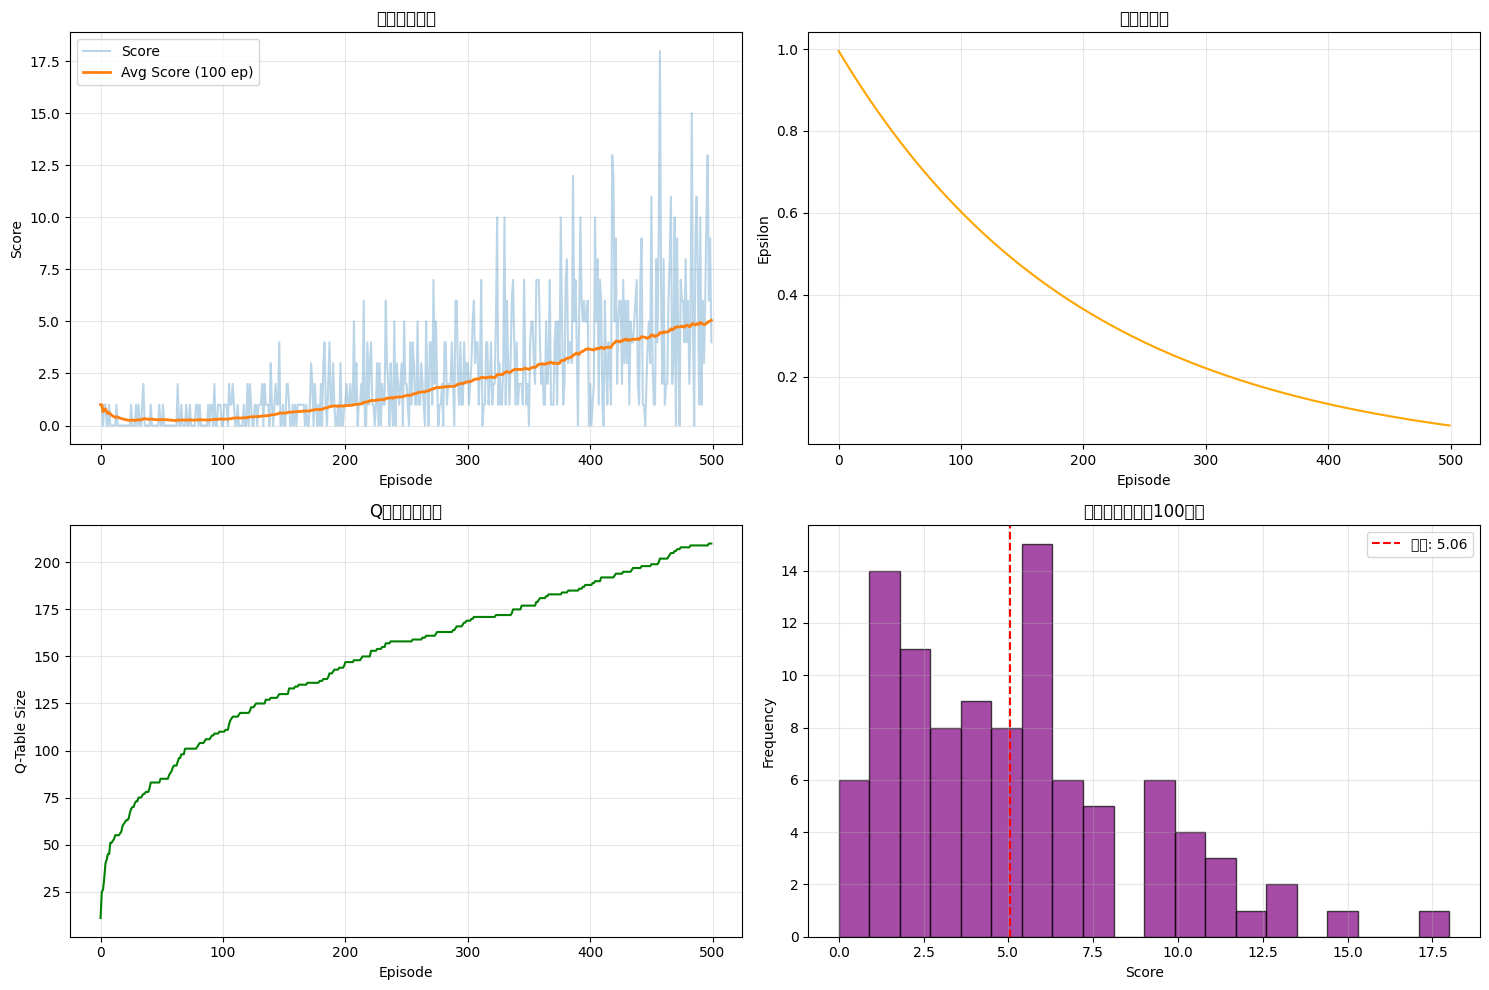

✅ 训练曲线已生成并保存！


In [8]:
ig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 得分曲线
axes[0, 0].plot(scores, alpha=0.3, label='Score')
axes[0, 0].plot(avg_scores, label='Avg Score (100 ep)', linewidth=2)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('训练得分变化')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Epsilon衰减
axes[0, 1].plot(epsilons, color='orange')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Epsilon')
axes[0, 1].set_title('探索率衰减')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q表增长
axes[1, 0].plot(q_table_sizes, color='green')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Q-Table Size')
axes[1, 0].set_title('Q表状态数增长')
axes[1, 0].grid(True, alpha=0.3)

# 4. 得分分布
recent_scores = scores[-100:] if len(scores) >= 100 else scores
axes[1, 1].hist(recent_scores, bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('得分分布（最后100轮）')
axes[1, 1].axvline(np.mean(recent_scores), color='red', linestyle='--',
                   label=f'平均: {np.mean(recent_scores):.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 训练曲线已生成并保存！")

In [9]:
print("=" * 60)
print("性能评估：随机策略 vs Q-Learning智能体")
print("=" * 60)

# 测试随机策略
print("\n测试随机策略（100局）...")
random_scores = []

for i in range(100):
    state = env.reset()
    done = False
    while not done:
        action_idx = np.random.randint(0, 3)
        action = np.zeros(3)
        action[action_idx] = 1
        state, reward, done, score = env.step(action)
    random_scores.append(score)

print(f"随机策略平均分: {np.mean(random_scores):.2f} ± {np.std(random_scores):.2f}")
print(f"随机策略最高分: {max(random_scores)}")

# 测试Q-Learning智能体
print("\n测试Q-Learning智能体（100局）...")
agent_scores = []

for i in range(100):
    state = env.reset()
    done = False
    while not done:
        action = agent.get_action(state, training=False)
        state, reward, done, score = env.step(action)
    agent_scores.append(score)

print(f"Q-Learning平均分: {np.mean(agent_scores):.2f} ± {np.std(agent_scores):.2f}")
print(f"Q-Learning最高分: {max(agent_scores)}")

# 计算性能提升
improvement = ((np.mean(agent_scores) - np.mean(random_scores)) / np.mean(random_scores) * 100)
print(f"\n✨ 性能提升: {improvement:.1f}%")
print("=" * 60)


性能评估：随机策略 vs Q-Learning智能体

测试随机策略（100局）...
随机策略平均分: 0.26 ± 0.52
随机策略最高分: 3

测试Q-Learning智能体（100局）...
Q-Learning平均分: 11.26 ± 7.43
Q-Learning最高分: 30

✨ 性能提升: 4230.8%


/tmp/ipykernel_330/2436696143.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([random_scores, agent_scores], labels=['Random', 'Q-Learning'])
/tmp/ipykernel_330/2436696143.py:18: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/2436696143.py:18: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/2436696143.py:18: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/2436696143.py:18: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330/2436696143.py:18: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font

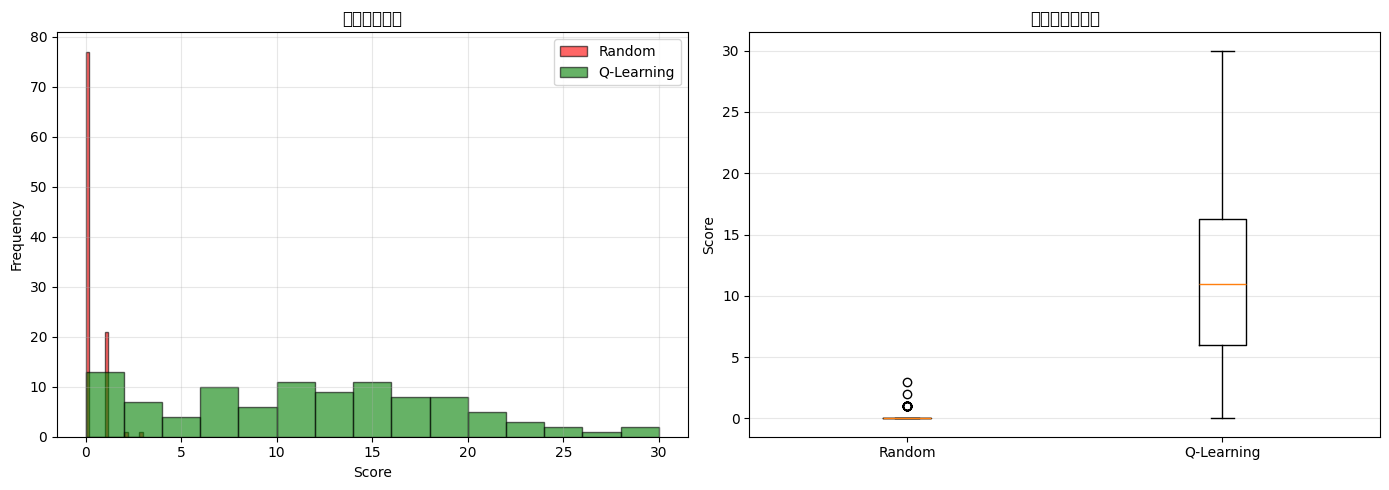

✅ 性能对比图已生成并保存！


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 得分分布对比
axes[0].hist(random_scores, bins=15, alpha=0.6, label='Random', color='red', edgecolor='black')
axes[0].hist(agent_scores, bins=15, alpha=0.6, label='Q-Learning', color='green', edgecolor='black')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('得分分布对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 箱线图对比
axes[1].boxplot([random_scores, agent_scores], labels=['Random', 'Q-Learning'])
axes[1].set_ylabel('Score')
axes[1].set_title('得分箱线图对比')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 性能对比图已生成并保存！")

In [11]:
print("\n" + "=" * 60)
print("训练统计分析")
print("=" * 60)

print(f"\n📊 总体表现:")
print(f"  最高分数: {max(scores)}")
print(f"  平均分数: {np.mean(scores):.2f}")
print(f"  中位数分数: {np.median(scores):.2f}")
print(f"  标准差: {np.std(scores):.2f}")

print(f"\n📈 学习进展:")
first_100_avg = np.mean(scores[:100])
last_100_avg = np.mean(scores[-100:])
improvement_pct = ((last_100_avg - first_100_avg) / first_100_avg * 100) if first_100_avg > 0 else 0
print(f"  前100轮平均: {first_100_avg:.2f}")
print(f"  后100轮平均: {last_100_avg:.2f}")
print(f"  性能提升: {improvement_pct:.1f}%")

print(f"\n🧠 Q表统计:")
print(f"  最终Q表大小: {q_table_sizes[-1]} 个状态")
print(f"  最终Epsilon: {epsilons[-1]:.4f}")
print(f"  训练步数: {agent.training_step}")

print("\n" + "=" * 60)


训练统计分析

📊 总体表现:
  最高分数: 18
  平均分数: 2.41
  中位数分数: 1.00
  标准差: 2.81

📈 学习进展:
  前100轮平均: 0.31
  后100轮平均: 5.06
  性能提升: 1532.3%

🧠 Q表统计:
  最终Q表大小: 210 个状态
  最终Epsilon: 0.0816
  训练步数: 16744

